# Seoul Bike Sharing Demand — análisis exploratorio

**Autor:** Francisco de la Corte  
**Fuente:** UCI Machine Learning Repository  
**Estado:** fase 1 — planteamiento, carga y auditoría inicial

> El análisis es descriptivo: identifica patrones y asociaciones en datos históricos, pero no demuestra causalidad.

## 1. Problema y propósito

Los sistemas públicos de bicicletas necesitan ajustar su disponibilidad a una demanda que cambia según la hora, el calendario y las condiciones meteorológicas.

**Pregunta principal:** ¿Cómo varía la demanda horaria del sistema público de bicicletas de Seúl en función del tiempo, las condiciones meteorológicas, la estación y los días festivos, y qué recomendaciones operativas pueden extraerse para mejorar la disponibilidad del servicio?

**Audiencia:** responsables de movilidad urbana y gestores del servicio.

**Uso previsto:** apoyar decisiones operativas y mostrar un proceso de análisis reproducible.

## 2. Preguntas analíticas

1. ¿Cuáles son las horas y los días con mayor y menor demanda?
2. ¿Cómo cambia la demanda entre estaciones?
3. ¿Qué diferencias aparecen entre festivos y días ordinarios?
4. ¿Cómo se relacionan temperatura, lluvia, nieve y humedad con los alquileres?
5. ¿Existen observaciones atípicas o periodos anómalos?
6. ¿Cuándo convendría reforzar o reducir la disponibilidad?
7. ¿Qué conclusiones son descriptivas y cuáles requerirían un modelo predictivo?

## 3. Fuente y límites iniciales

- Dataset: **Seoul Bike Sharing Demand**.
- Fuente oficial: https://archive.ics.uci.edu/dataset/560/seoul%2Bbike%2Bsharing%2Bdemand
- DOI: https://doi.org/10.24432/C5F62R
- Unidad de observación: una hora.
- Cobertura declarada: 8.760 observaciones.
- UCI no declara valores ausentes.
- Los resultados no deben generalizarse automáticamente a otras ciudades o periodos.

## 4. Carga reproducible

Se utiliza el identificador permanente de UCI. Se combinan variables predictoras y objetivo evitando columnas duplicadas.

In [4]:
# Instalación de la librería necesaria para descargar el dataset desde UCI
%pip install -q ucimlrepo

# Librerías
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Configuración
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="deep")

# Semilla para garantizar resultados reproducibles
RANDOM_STATE = 42

print("Librerías instaladas e importadas correctamente.")

Librerías instaladas e importadas correctamente.


In [5]:
dataset = fetch_ucirepo(id=560)

features = dataset.data.features.copy()
targets = dataset.data.targets.copy() if dataset.data.targets is not None else pd.DataFrame()

if not targets.empty:
    new_target_columns = [c for c in targets.columns if c not in features.columns]
    df_raw = pd.concat([features, targets[new_target_columns]], axis=1)
else:
    df_raw = features.copy()

df = df_raw.copy()
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
display(df.head())

Dimensiones: 8,760 filas × 14 columnas


,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day
0,1/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,1/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,1/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,1/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,1/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [6]:
# Metadatos y diccionario facilitados por UCI
display(dataset.variables)
print(dataset.metadata.get("name", "Seoul Bike Sharing Demand"))

,name,role,type,demographic,description,units,missing_values
0,Date,Feature,Date,None,None,None,no
1,Rented Bike Count,Feature,Integer,None,None,None,no
2,Hour,Feature,Integer,None,None,None,no
3,Temperature,Feature,Continuous,None,None,C,no
4,Humidity,Feature,Integer,None,None,%,no
5,Wind speed,Feature,Continuous,None,None,m/s,no
6,Visibility,Feature,Integer,None,None,10m,no
7,Dew point temperature,Feature,Continuous,None,None,C,no
8,Solar Radiation,Feature,Continuous,None,None,Mj/m2,no
9,Rainfall,Feature,Integer,None,None,mm,no


Seoul Bike Sharing Demand


## 5. Auditoría inicial de calidad

Antes de limpiar o representar datos se comprueban dimensiones, tipos, ausencias, duplicados y cardinalidad. Cualquier transformación posterior deberá justificarse.

In [7]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_n": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_n": df.nunique(dropna=False)
}).sort_values(["missing_pct", "unique_n"], ascending=[False, True])

print(f"Filas duplicadas completas: {df.duplicated().sum():,}")
display(audit)

Filas duplicadas completas: 0


,dtype,missing_n,missing_pct,unique_n
Holiday,object,0,0.0,2
Functioning Day,object,0,0.0,2
Seasons,object,0,0.0,4
Hour,int64,0,0.0,24
Snowfall,float64,0,0.0,51
Rainfall,float64,0,0.0,61
Wind speed,float64,0,0.0,65
Humidity,int64,0,0.0,90
Solar Radiation,float64,0,0.0,345
Date,object,0,0.0,365


In [8]:
# Resumen descriptivo sin modificar todavía los datos
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,8760,365,30/11/2018,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rented Bike Count,8760.0,NaN,NaN,NaN,704.602055,644.997468,0.0,191.0,504.5,1065.25,3556.0
Hour,8760.0,NaN,NaN,NaN,11.5,6.922582,0.0,5.75,11.5,17.25,23.0
Temperature,8760.0,NaN,NaN,NaN,12.882922,11.944825,-17.8,3.5,13.7,22.5,39.4
Humidity,8760.0,NaN,NaN,NaN,58.226256,20.362413,0.0,42.0,57.0,74.0,98.0
Wind speed,8760.0,NaN,NaN,NaN,1.724909,1.0363,0.0,0.9,1.5,2.3,7.4
Visibility,8760.0,NaN,NaN,NaN,1436.825799,608.298712,27.0,940.0,1698.0,2000.0,2000.0
Dew point temperature,8760.0,NaN,NaN,NaN,4.073813,13.060369,-30.6,-4.7,5.1,14.8,27.2
Solar Radiation,8760.0,NaN,NaN,NaN,0.569111,0.868746,0.0,0.0,0.01,0.93,3.52
Rainfall,8760.0,NaN,NaN,NaN,0.148687,1.128193,0.0,0.0,0.0,0.0,35.0


## 6. Validaciones de coherencia

Antes de limpiar los datos se revisan la cobertura temporal, las interrupciones del servicio, los registros con demanda igual a cero y los rangos de las variables meteorológicas.

In [10]:
# Validaciones de coherencia antes de limpiar

print("Rango de fechas:")
print(df["Date"].min(), "→", df["Date"].max())

print("\nDistribución del funcionamiento del servicio:")
display(
    df["Functioning Day"]
    .value_counts(dropna=False)
    .to_frame("Número de horas")
)

print("\nRegistros con demanda igual a cero:")
print((df["Rented Bike Count"] == 0).sum())

print("\nDemanda cero según funcionamiento del servicio:")
display(
    pd.crosstab(
        df["Functioning Day"],
        df["Rented Bike Count"] == 0,
        rownames=["Servicio operativo"],
        colnames=["Demanda igual a cero"]
    )
)

print("\nValores mínimos y máximos de las variables meteorológicas:")
display(
    df[
        [
            "Temperature",
            "Humidity",
            "Wind speed",
            "Visibility",
            "Solar Radiation",
            "Rainfall",
            "Snowfall"
        ]
    ].agg(["min", "max"]).T
)

Rango de fechas:
1/1/2018 → 9/9/2018

Distribución del funcionamiento del servicio:


,Número de horas
Functioning Day,
Yes,8465
No,295



Registros con demanda igual a cero:
295

Demanda cero según funcionamiento del servicio:


Demanda igual a cero,False,True
Servicio operativo,,
No,0,295
Yes,8465,0



Valores mínimos y máximos de las variables meteorológicas:


,min,max
Temperature,-17.8,39.40
Humidity,0.0,98.00
Wind speed,0.0,7.40
Visibility,27.0,2000.00
Solar Radiation,0.0,3.52
Rainfall,0.0,35.00
Snowfall,0.0,8.80


## 7. Preparación y transformación

Se convierte la fecha a un formato temporal válido, se construye una marca temporal horaria y se separan las horas operativas para analizar la demanda realmente observada. El dataset original se conserva sin modificar.

In [12]:
# Copia de trabajo: el dataframe original se conserva sin modificar
df_clean = df.copy()

# Conversión explícita del formato día/mes/año
df_clean["Date"] = pd.to_datetime(
    df_clean["Date"],
    format="%d/%m/%Y",
    errors="coerce"
)

# Comprobación de fechas no interpretadas
print("Fechas no interpretadas:", df_clean["Date"].isna().sum())

# Creación de una marca temporal completa
df_clean["Datetime"] = (
    df_clean["Date"]
    + pd.to_timedelta(df_clean["Hour"], unit="h")
)

print(
    "Rango temporal correcto:",
    df_clean["Datetime"].min(),
    "→",
    df_clean["Datetime"].max()
)

# Separación de las horas con servicio operativo
df_operational = df_clean[
    df_clean["Functioning Day"] == "Yes"
].copy()

print(f"\nDataset completo: {len(df_clean):,} registros")
print(f"Horas operativas: {len(df_operational):,} registros")
print(
    "Ceros de demanda en horas operativas:",
    (df_operational["Rented Bike Count"] == 0).sum()
)

# Inspección del valor potencialmente sospechoso de humedad
print("\nRegistros con humedad igual a 0 %:")
display(
    df_clean.loc[
        df_clean["Humidity"] == 0,
        [
            "Datetime",
            "Temperature",
            "Humidity",
            "Dew point temperature",
            "Rented Bike Count",
            "Functioning Day"
        ]
    ]
)

Fechas no interpretadas: 0
Rango temporal correcto: 2017-12-01 00:00:00 → 2018-11-30 23:00:00

Dataset completo: 8,760 registros
Horas operativas: 8,465 registros
Ceros de demanda en horas operativas: 0

Registros con humedad igual a 0 %:


,Datetime,Temperature,Humidity,Dew point temperature,Rented Bike Count,Functioning Day
4063,2018-05-19 07:00:00,11.4,0,4.5,436,Yes
4106,2018-05-21 02:00:00,13.9,0,-2.1,262,Yes
4107,2018-05-21 03:00:00,13.0,0,-2.5,165,Yes
4108,2018-05-21 04:00:00,12.4,0,-3.4,113,Yes
4109,2018-05-21 05:00:00,11.9,0,-2.7,200,Yes
4110,2018-05-21 06:00:00,11.4,0,-2.0,467,Yes
4111,2018-05-21 07:00:00,12.3,0,-2.7,1135,Yes
4131,2018-05-22 03:00:00,15.5,0,10.4,406,Yes
4132,2018-05-22 04:00:00,15.6,0,10.5,248,Yes
4133,2018-05-22 05:00:00,15.7,0,10.6,182,Yes


## 8. Tratamiento de anomalías de calidad

Se detectaron 17 registros con humedad relativa igual a 0 %, concentrados entre el 19 y el 28 de mayo de 2018. Estos valores son incompatibles con la temperatura y el punto de rocío registrados, por lo que se consideran fallos puntuales de medición.

La humedad se estima mediante la fórmula de Magnus utilizando la temperatura y el punto de rocío. Se conserva la variable original para mantener la trazabilidad.

In [13]:
# Conservación de la humedad original
df_clean["Humidity_original"] = df_clean["Humidity"]

# Registros que requieren corrección
humidity_mask = df_clean["Humidity"].eq(0)

# Estimación de humedad relativa mediante la fórmula de Magnus
a = 17.625
b = 243.04

temperature = df_clean["Temperature"]
dew_point = df_clean["Dew point temperature"]

estimated_humidity = 100 * np.exp(
    (a * dew_point / (b + dew_point))
    - (a * temperature / (b + temperature))
)

# La columna pasa a decimal para admitir valores estimados
df_clean["Humidity"] = df_clean["Humidity"].astype(float)

df_clean.loc[humidity_mask, "Humidity"] = (
    estimated_humidity[humidity_mask]
    .clip(0, 100)
    .round(1)
)

print("Registros corregidos:", humidity_mask.sum())

display(
    df_clean.loc[
        humidity_mask,
        [
            "Datetime",
            "Temperature",
            "Dew point temperature",
            "Humidity_original",
            "Humidity"
        ]
    ]
)

# Actualización del subconjunto operativo
df_operational = df_clean[
    df_clean["Functioning Day"] == "Yes"
].copy()

Registros corregidos: 17


,Datetime,Temperature,Dew point temperature,Humidity_original,Humidity
4063,2018-05-19 07:00:00,11.4,4.5,0,62.5
4106,2018-05-21 02:00:00,13.9,-2.1,0,33.1
4107,2018-05-21 03:00:00,13.0,-2.5,0,34.0
4108,2018-05-21 04:00:00,12.4,-3.4,0,33.1
4109,2018-05-21 05:00:00,11.9,-2.7,0,36.0
4110,2018-05-21 06:00:00,11.4,-2.0,0,39.2
4111,2018-05-21 07:00:00,12.3,-2.7,0,35.1
4131,2018-05-22 03:00:00,15.5,10.4,0,71.6
4132,2018-05-22 04:00:00,15.6,10.5,0,71.7
4133,2018-05-22 05:00:00,15.7,10.6,0,71.7


## 9. Análisis univariante de la demanda

Se analiza la distribución de bicicletas alquiladas únicamente durante las horas en las que el servicio estuvo operativo. Los posibles valores atípicos se identifican para estudiarlos, pero no se eliminan automáticamente.

,Rented Bike Count
count,8465.000000
mean,729.156999
std,642.351166
min,2.000000
1%,17.000000
5%,49.000000
25%,214.000000
50%,542.000000
75%,1084.000000
95%,2058.800000


Límite inferior IQR: -1,091.0
Límite superior IQR: 2,389.0
Registros fuera de los límites IQR: 152
Porcentaje sobre las horas operativas: 1.80%


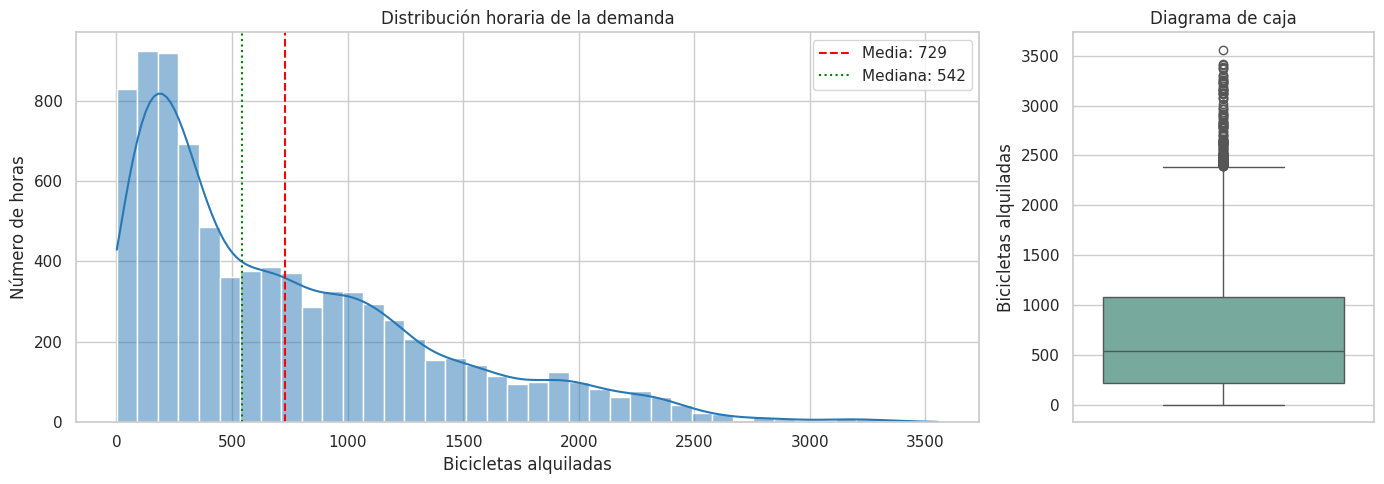

In [14]:
# Variable principal durante las horas operativas
demand = df_operational["Rented Bike Count"]

# Resumen con percentiles adicionales
demand_summary = demand.describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).to_frame("Rented Bike Count")

display(demand_summary)

# Identificación descriptiva de valores extremos mediante el criterio IQR
q1 = demand.quantile(0.25)
q3 = demand.quantile(0.75)
iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

extreme_values = demand[
    (demand < lower_limit) | (demand > upper_limit)
]

print(f"Límite inferior IQR: {lower_limit:,.1f}")
print(f"Límite superior IQR: {upper_limit:,.1f}")
print(f"Registros fuera de los límites IQR: {len(extreme_values):,}")
print(
    "Porcentaje sobre las horas operativas:",
    f"{len(extreme_values) / len(demand) * 100:.2f}%"
)

# Distribución y diagrama de caja
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    gridspec_kw={"width_ratios": [3, 1]}
)

sns.histplot(
    demand,
    bins=40,
    kde=True,
    ax=axes[0],
    color="#2878B5"
)

axes[0].axvline(
    demand.mean(),
    color="red",
    linestyle="--",
    label=f"Media: {demand.mean():.0f}"
)

axes[0].axvline(
    demand.median(),
    color="green",
    linestyle=":",
    label=f"Mediana: {demand.median():.0f}"
)

axes[0].set_title("Distribución horaria de la demanda")
axes[0].set_xlabel("Bicicletas alquiladas")
axes[0].set_ylabel("Número de horas")
axes[0].legend()

sns.boxplot(
    y=demand,
    ax=axes[1],
    color="#6FB1A0"
)

axes[1].set_title("Diagrama de caja")
axes[1].set_ylabel("Bicicletas alquiladas")

plt.tight_layout()
plt.show()

## 10. Registro de decisiones y limitaciones